In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
DATASET_DIR = Path("test")

scenes = sorted(DATASET_DIR.iterdir())

print("Number of scenes:", len(scenes))
print("Scenes:", [scene.name for scene in scenes])

Number of scenes: 12
Scenes: ['000048', '000049', '000050', '000051', '000052', '000053', '000054', '000055', '000056', '000057', '000058', '000059']


In [3]:
def load_scene(scene_dir):

    scene_gt_path = scene_dir / "scene_gt.json"

    with open(scene_gt_path, "r") as f:

        scene_gt = json.load(f)

    samples = []

    for frame_id, objects in scene_gt.items():

        rgb_path = scene_dir / "rgb" / f"{int(frame_id):06d}.png"

        for instance_id, obj in enumerate(objects):

            mask_path = (

                scene_dir

                / "mask_visib"

                / f"{int(frame_id):06d}_{instance_id:06d}.png"

            )

            samples.append({

                "scene_id": scene_dir.name,

                "frame_id": int(frame_id),

                "instance_id": instance_id,

                "obj_id": obj["obj_id"],

                "rgb_path": rgb_path,

                "mask_path": mask_path

            })

    return pd.DataFrame(samples)

In [4]:
scene_df = load_scene(DATASET_DIR / "000048")

print("Number of samples:", len(scene_df))
scene_df.head()

Number of samples: 375


,scene_id,frame_id,instance_id,obj_id,rgb_path,mask_path
0,000048,1,0,1,test/000048/rgb/000001.png,test/000048/mask_visib/000001_000000.png
1,000048,1,1,6,test/000048/rgb/000001.png,test/000048/mask_visib/000001_000001.png
2,000048,1,2,14,test/000048/rgb/000001.png,test/000048/mask_visib/000001_000002.png
3,000048,1,3,19,test/000048/rgb/000001.png,test/000048/mask_visib/000001_000003.png
4,000048,1,4,20,test/000048/rgb/000001.png,test/000048/mask_visib/000001_000004.png


In [5]:
print("Dataset shape:", scene_df.shape)

print("\nColumns:")
print(scene_df.columns.tolist())

print("\nUnique objects:", scene_df["obj_id"].nunique())
print("Object IDs:", sorted(scene_df["obj_id"].unique()))

print("\nSamples per object:")
print(scene_df["obj_id"].value_counts().sort_index())

Dataset shape: (375, 6)

Columns:
['scene_id', 'frame_id', 'instance_id', 'obj_id', 'rgb_path', 'mask_path']

Unique objects: 5
Object IDs: [np.int64(1), np.int64(6), np.int64(14), np.int64(19), np.int64(20)]

Samples per object:
obj_id
1     75
6     75
14    75
19    75
20    75
Name: count, dtype: int64


In [6]:
scene_df["rgb_exists"] = scene_df["rgb_path"].apply(Path.exists)
scene_df["mask_exists"] = scene_df["mask_path"].apply(Path.exists)

print("RGB files found:", scene_df["rgb_exists"].sum())
print("RGB files missing:", (~scene_df["rgb_exists"]).sum())

print("Mask files found:", scene_df["mask_exists"].sum())
print("Mask files missing:", (~scene_df["mask_exists"]).sum())

RGB files found: 375
RGB files missing: 0
Mask files found: 375
Mask files missing: 0


In [7]:
sample = scene_df.iloc[0]

print("Scene:", sample["scene_id"])
print("Frame:", sample["frame_id"])
print("Instance:", sample["instance_id"])
print("Object ID:", sample["obj_id"])
print("RGB:", sample["rgb_path"])
print("Mask:", sample["mask_path"])

Scene: 000048
Frame: 1
Instance: 0
Object ID: 1
RGB: test/000048/rgb/000001.png
Mask: test/000048/mask_visib/000001_000000.png


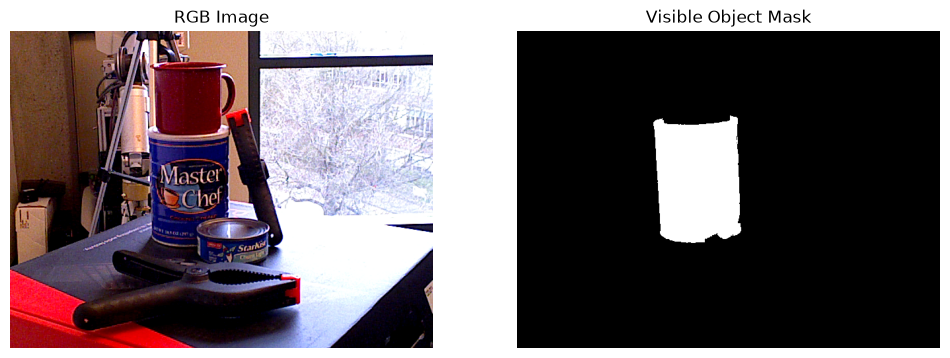

In [8]:
rgb_image = Image.open(sample["rgb_path"])
mask_image = Image.open(sample["mask_path"])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Visible Object Mask")
plt.axis("off")

plt.show()

In [9]:
def extract_features(row):
    rgb = np.array(Image.open(row["rgb_path"]).convert("RGB"))
    mask = np.array(Image.open(row["mask_path"]).convert("L"))

    # Object pixels
    object_pixels = rgb[mask > 0]

    # If mask is empty
    if len(object_pixels) == 0:
        return pd.Series({
            "mean_r": np.nan,
            "mean_g": np.nan,
            "mean_b": np.nan,
            "std_r": np.nan,
            "std_g": np.nan,
            "std_b": np.nan,
            "area_ratio": 0,
            "bbox_width": 0,
            "bbox_height": 0,
            "aspect_ratio": 0
        })

    # Color features
    mean_rgb = object_pixels.mean(axis=0)
    std_rgb = object_pixels.std(axis=0)

    # Mask coordinates
    ys, xs = np.where(mask > 0)

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    bbox_width = x_max - x_min + 1
    bbox_height = y_max - y_min + 1

    # Object area relative to image
    area_ratio = len(object_pixels) / mask.size

    # Bounding-box aspect ratio
    aspect_ratio = bbox_width / bbox_height

    return pd.Series({
        "mean_r": mean_rgb[0],
        "mean_g": mean_rgb[1],
        "mean_b": mean_rgb[2],
        "std_r": std_rgb[0],
        "std_g": std_rgb[1],
        "std_b": std_rgb[2],
        "area_ratio": area_ratio,
        "bbox_width": bbox_width,
        "bbox_height": bbox_height,
        "aspect_ratio": aspect_ratio
    })


features_df = scene_df.apply(extract_features, axis=1)

features_df.head()

,mean_r,mean_g,mean_b,std_r,std_g,std_b,area_ratio,bbox_width,bbox_height,aspect_ratio
0,69.954669,45.831608,79.993787,71.974350,60.666593,58.407435,0.070732,133.0,193.0,0.689119
1,79.557272,66.206397,96.343630,64.322034,61.191159,61.653736,0.023815,113.0,74.0,1.527027
2,102.263805,19.087580,27.331640,43.416172,48.244696,48.533146,0.039733,138.0,114.0,1.210526
3,75.379968,52.565655,67.722342,86.667902,82.716625,84.079763,0.024245,91.0,214.0,0.425234
4,41.976002,26.518328,37.284100,54.710035,47.581357,61.498735,0.081523,350.0,128.0,2.734375


In [10]:
model_df = pd.concat(
    [scene_df[["scene_id", "frame_id", "instance_id", "obj_id"]], features_df],
    axis=1
)

print("Model dataset shape:", model_df.shape)

model_df.head()

Model dataset shape: (375, 14)


,scene_id,frame_id,instance_id,obj_id,mean_r,mean_g,mean_b,std_r,std_g,std_b,area_ratio,bbox_width,bbox_height,aspect_ratio
0,000048,1,0,1,69.954669,45.831608,79.993787,71.974350,60.666593,58.407435,0.070732,133.0,193.0,0.689119
1,000048,1,1,6,79.557272,66.206397,96.343630,64.322034,61.191159,61.653736,0.023815,113.0,74.0,1.527027
2,000048,1,2,14,102.263805,19.087580,27.331640,43.416172,48.244696,48.533146,0.039733,138.0,114.0,1.210526
3,000048,1,3,19,75.379968,52.565655,67.722342,86.667902,82.716625,84.079763,0.024245,91.0,214.0,0.425234
4,000048,1,4,20,41.976002,26.518328,37.284100,54.710035,47.581357,61.498735,0.081523,350.0,128.0,2.734375


In [11]:
feature_columns = [
    "mean_r",
    "mean_g",
    "mean_b",
    "std_r",
    "std_g",
    "std_b",
    "area_ratio",
    "bbox_width",
    "bbox_height",
    "aspect_ratio"
]

X = model_df[feature_columns]
y = model_df["obj_id"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts().sort_index())

X shape: (375, 10)
y shape: (375,)

Class distribution:
obj_id
1     75
6     75
14    75
19    75
20    75
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

# First split: 80% temporary, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 60% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (225, 10)
Validation: (75, 10)
Test: (75, 10)


In [13]:
print("Train distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation distribution:")
print(y_val.value_counts().sort_index())

print("\nTest distribution:")
print(y_test.value_counts().sort_index())

Train distribution:
obj_id
1     45
6     45
14    45
19    45
20    45
Name: count, dtype: int64

Validation distribution:
obj_id
1     15
6     15
14    15
19    15
20    15
Name: count, dtype: int64

Test distribution:
obj_id
1     15
6     15
14    15
19    15
20    15
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Train scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

Train scaled shape: (225, 10)
Validation scaled shape: (75, 10)
Test scaled shape: (75, 10)


In [15]:
print("Train means after scaling:")
print(X_train_scaled.mean(axis=0))

print("\nTrain standard deviations after scaling:")
print(X_train_scaled.std(axis=0))

Train means after scaling:
[-1.03423443e-15 -8.00840875e-16 -2.59298755e-16  2.74545818e-15
  2.43755633e-16 -1.11734696e-15  2.09215361e-16 -2.43755633e-16
  1.55924656e-16  1.00166788e-15]

Train standard deviations after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [17]:
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Predictions generated successfully")

print("\nTrain predictions:", len(y_train_pred))
print("Validation predictions:", len(y_val_pred))
print("Test predictions:", len(y_test_pred))

Predictions generated successfully

Train predictions: 225
Validation predictions: 75
Test predictions: 75


In [18]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 1.0
Validation Accuracy: 1.0
Test Accuracy: 1.0


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

val_precision = precision_score(
    y_val,
    y_val_pred,
    average="weighted"
)

val_recall = recall_score(
    y_val,
    y_val_pred,
    average="weighted"
)

val_f1 = f1_score(
    y_val,
    y_val_pred,
    average="weighted"
)

print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1:", val_f1)

Validation Precision: 1.0
Validation Recall: 1.0
Validation F1: 1.0


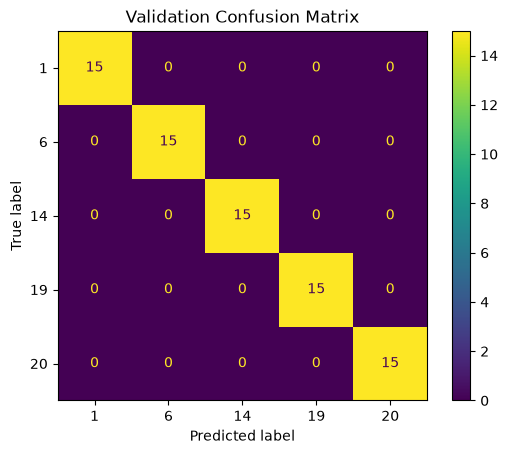

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_val,
    y_val_pred,
    labels=sorted(y.unique())
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

In [21]:
val_errors = y_val != y_val_pred
test_errors = y_test != y_test_pred

print("Validation errors:", val_errors.sum())
print("Test errors:", test_errors.sum())

print("Validation error rate:", val_errors.mean())
print("Test error rate:", test_errors.mean())

Validation errors: 0
Test errors: 0
Validation error rate: 0.0
Test error rate: 0.0


In [22]:
results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Samples": [len(y_train), len(y_val), len(y_test)],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_val, y_val_pred),
        accuracy_score(y_test, y_test_pred)
    ]
})

results

,Dataset,Samples,Accuracy
0,Train,225,1.0
1,Validation,75,1.0
2,Test,75,1.0


In [23]:
feature_summary = model_df.groupby("obj_id")[feature_columns].mean()

feature_summary

,mean_r,mean_g,mean_b,std_r,std_g,std_b,area_ratio,bbox_width,bbox_height,aspect_ratio
obj_id,,,,,,,,,,
1,66.089545,34.969699,54.038580,65.376473,49.571506,48.960211,0.047160,120.813333,170.773333,0.708355
6,81.374185,53.461449,65.444107,59.427187,47.346343,42.269939,0.018695,99.920000,66.613333,1.497998
14,115.163361,24.640612,32.164429,45.862257,54.570494,60.458574,0.031143,126.386667,102.440000,1.232883
19,54.091420,35.547214,49.336278,58.612998,46.745862,58.519716,0.034273,110.200000,199.093333,0.551040
20,58.022471,24.158401,26.583564,60.522297,32.812164,35.704243,0.040378,221.320000,118.906667,1.861859


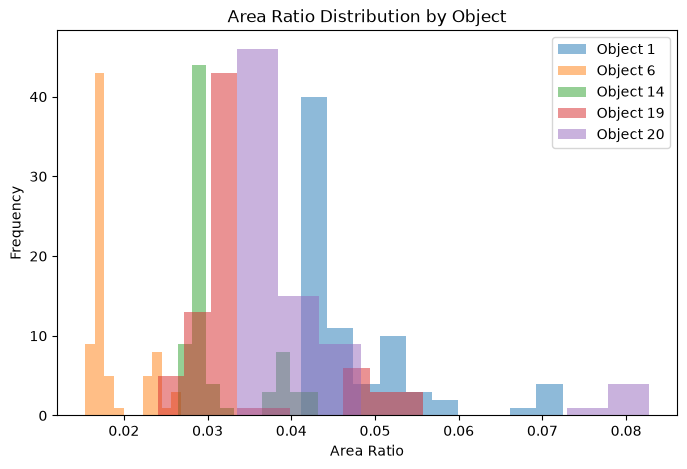

In [24]:
plt.figure(figsize=(8, 5))

for obj_id in sorted(model_df["obj_id"].unique()):
    values = model_df.loc[
        model_df["obj_id"] == obj_id,
        "area_ratio"
    ]

    plt.hist(
        values,
        alpha=0.5,
        label=f"Object {obj_id}"
    )

plt.xlabel("Area Ratio")
plt.ylabel("Frequency")
plt.title("Area Ratio Distribution by Object")
plt.legend()
plt.show()

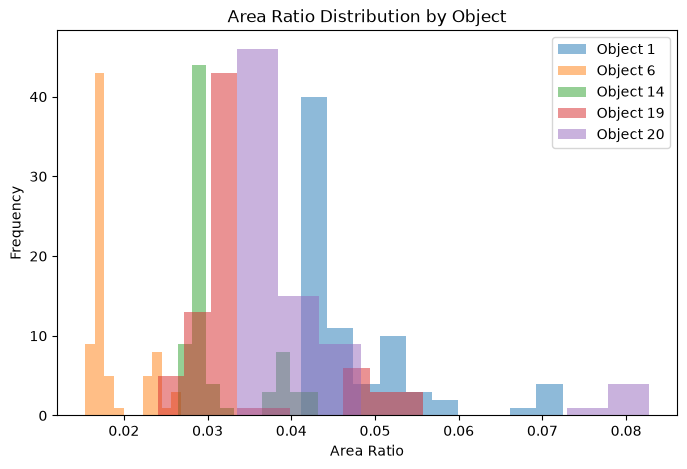

In [25]:
plt.figure(figsize=(8, 5))

for obj_id in sorted(model_df["obj_id"].unique()):
    values = model_df.loc[
        model_df["obj_id"] == obj_id,
        "area_ratio"
    ]

    plt.hist(
        values,
        alpha=0.5,
        label=f"Object {obj_id}"
    )

plt.xlabel("Area Ratio")
plt.ylabel("Frequency")
plt.title("Area Ratio Distribution by Object")
plt.legend()
plt.show()

In [26]:
print("Number of scenes:", len(scenes))
print("Scenes:")

for scene in scenes:
    print(scene.name)

Number of scenes: 12
Scenes:
000048
000049
000050
000051
000052
000053
000054
000055
000056
000057
000058
000059


In [27]:
accuracy_gap_train_val = train_accuracy - val_accuracy
accuracy_gap_val_test = val_accuracy - test_accuracy

print("Train Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)
print("Test Accuracy:", test_accuracy)

print("\nTrain - Validation gap:", accuracy_gap_train_val)
print("Validation - Test gap:", accuracy_gap_val_test)

Train Accuracy: 1.0
Validation Accuracy: 1.0
Test Accuracy: 1.0

Train - Validation gap: 0.0
Validation - Test gap: 0.0


In [28]:
train_correct = (y_train == y_train_pred).sum()
val_correct = (y_val == y_val_pred).sum()
test_correct = (y_test == y_test_pred).sum()

print(f"Train: {train_correct}/{len(y_train)} correct")
print(f"Validation: {val_correct}/{len(y_val)} correct")
print(f"Test: {test_correct}/{len(y_test)} correct")

Train: 225/225 correct
Validation: 75/75 correct
Test: 75/75 correct


In [29]:
all_scene_dfs = []

for scene_dir in scenes:
    scene_data = load_scene(scene_dir)
    all_scene_dfs.append(scene_data)

all_scene_df = pd.concat(
    all_scene_dfs,
    ignore_index=True
)

print("Total samples:", len(all_scene_df))
print("Total scenes:", all_scene_df["scene_id"].nunique())
print("\nSamples per scene:")
print(all_scene_df["scene_id"].value_counts().sort_index())

print("\nObjects:")
print(sorted(all_scene_df["obj_id"].unique()))

Total samples: 4125
Total scenes: 12

Samples per scene:
scene_id
000048    375
000049    300
000050    375
000051    375
000052    225
000053    225
000054    375
000055    450
000056    300
000057    375
000058    300
000059    450
Name: count, dtype: int64

Objects:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]


In [30]:
all_features_df = all_scene_df.apply(
    extract_features,
    axis=1
)

all_model_df = pd.concat(
    [
        all_scene_df[
            ["scene_id", "frame_id", "instance_id", "obj_id"]
        ],
        all_features_df
    ],
    axis=1
)

print("Full model dataset shape:", all_model_df.shape)

all_model_df.head()

Full model dataset shape: (4125, 14)


,scene_id,frame_id,instance_id,obj_id,mean_r,mean_g,mean_b,std_r,std_g,std_b,area_ratio,bbox_width,bbox_height,aspect_ratio
0,000048,1,0,1,69.954669,45.831608,79.993787,71.974350,60.666593,58.407435,0.070732,133.0,193.0,0.689119
1,000048,1,1,6,79.557272,66.206397,96.343630,64.322034,61.191159,61.653736,0.023815,113.0,74.0,1.527027
2,000048,1,2,14,102.263805,19.087580,27.331640,43.416172,48.244696,48.533146,0.039733,138.0,114.0,1.210526
3,000048,1,3,19,75.379968,52.565655,67.722342,86.667902,82.716625,84.079763,0.024245,91.0,214.0,0.425234
4,000048,1,4,20,41.976002,26.518328,37.284100,54.710035,47.581357,61.498735,0.081523,350.0,128.0,2.734375


In [31]:
print("Class distribution across all scenes:")

print(
    all_model_df["obj_id"]
    .value_counts()
    .sort_index()
)

print("\nClass distribution by scene:")

print(
    pd.crosstab(
        all_model_df["scene_id"],
        all_model_df["obj_id"]
    )
)

Class distribution across all scenes:
obj_id
1     300
2     225
3     375
4     450
5     150
6     300
7      75
8      75
9     225
10    150
11    225
12    300
13    150
14    150
15    300
16     75
17     75
18    150
19    150
20    150
21     75
Name: count, dtype: int64

Class distribution by scene:
obj_id    1   2   3   4   5   6   7   8   9   10  ...  12  13  14  15  16  17  \
scene_id                                          ...                           
000048    75   0   0   0   0  75   0   0   0   0  ...   0   0  75   0   0   0   
000049     0   0  75   0   0  75   0   0  75   0  ...   0  75   0   0   0   0   
000050     0  75   0  75  75   0   0   0   0  75  ...   0   0   0  75   0   0   
000051    75   0  75  75   0   0   0   0   0   0  ...  75   0   0   0   0  75   
000052     0   0   0   0  75  75   0   0   0   0  ...   0   0   0   0   0   0   
000053     0   0   0  75   0   0   0   0  75   0  ...   0  75   0   0   0   0   
000054     0  75  75   0   0   0   0   0 

In [32]:
scene_classes = (
    all_model_df
    .groupby("scene_id")["obj_id"]
    .apply(lambda x: set(x))
)

for scene_id, classes in scene_classes.items():
    print(scene_id, "→", sorted(classes))

000048 → [1, 6, 14, 19, 20]
000049 → [3, 6, 9, 13]
000050 → [2, 4, 5, 10, 15]
000051 → [1, 3, 4, 12, 17]
000052 → [5, 6, 11]
000053 → [4, 9, 13]
000054 → [2, 3, 12, 15, 19]
000055 → [1, 3, 4, 12, 14, 16]
000056 → [1, 10, 11, 15]
000057 → [4, 12, 18, 20, 21]
000058 → [3, 7, 8, 11]
000059 → [2, 4, 6, 9, 15, 18]


In [33]:
target_scene = "000048"
target_classes = scene_classes[target_scene]

print("Target scene:", target_scene)
print("Target classes:", sorted(target_classes))

print("\nOverlap with other scenes:")

for scene_id, classes in scene_classes.items():
    if scene_id == target_scene:
        continue

    overlap = target_classes.intersection(classes)

    print(
        scene_id,
        "→",
        len(overlap),
        "shared classes:",
        sorted(overlap)
    )

Target scene: 000048
Target classes: [1, 6, 14, 19, 20]

Overlap with other scenes:
000049 → 1 shared classes: [6]
000050 → 0 shared classes: []
000051 → 1 shared classes: [1]
000052 → 1 shared classes: [6]
000053 → 0 shared classes: []
000054 → 1 shared classes: [19]
000055 → 2 shared classes: [1, 14]
000056 → 1 shared classes: [1]
000057 → 1 shared classes: [20]
000058 → 0 shared classes: []
000059 → 1 shared classes: [6]


In [34]:
target_scene = "000048"

target_classes = set(
    all_model_df.loc[
        all_model_df["scene_id"] == target_scene,
        "obj_id"
    ]
)

print("Target classes:", sorted(target_classes))

print("\nScenes containing target classes:")

for scene_id, classes in scene_classes.items():

    if scene_id == target_scene:
        continue

    shared_classes = target_classes.intersection(classes)

    if shared_classes:
        print(
            scene_id,
            "→",
            sorted(shared_classes)
        )

Target classes: [1, 6, 14, 19, 20]

Scenes containing target classes:
000049 → [6]
000051 → [1]
000052 → [6]
000054 → [19]
000055 → [1, 14]
000056 → [1]
000057 → [20]
000059 → [6]


In [35]:
target_scene = "000048"

target_classes = sorted(
    all_model_df.loc[
        all_model_df["scene_id"] == target_scene,
        "obj_id"
    ].unique()
)

train_pool_df = all_model_df[
    (all_model_df["scene_id"] != target_scene) &
    (all_model_df["obj_id"].isin(target_classes))
].copy()

print("Target classes:", target_classes)

print("\nTraining pool shape:", train_pool_df.shape)

print("\nScenes in training pool:")
print(sorted(train_pool_df["scene_id"].unique()))

print("\nClass distribution:")
print(
    train_pool_df["obj_id"]
    .value_counts()
    .sort_index()
)

Target classes: [np.int64(1), np.int64(6), np.int64(14), np.int64(19), np.int64(20)]

Training pool shape: (675, 14)

Scenes in training pool:
['000049', '000051', '000052', '000054', '000055', '000056', '000057', '000059']

Class distribution:
obj_id
1     225
6     225
14     75
19     75
20     75
Name: count, dtype: int64


In [36]:
scene_class_counts = pd.crosstab(
    train_pool_df["scene_id"],
    train_pool_df["obj_id"]
)

print(scene_class_counts)

obj_id    1   6   14  19  20
scene_id                    
000049     0  75   0   0   0
000051    75   0   0   0   0
000052     0  75   0   0   0
000054     0   0   0  75   0
000055    75   0  75   0   0
000056    75   0   0   0   0
000057     0   0   0   0  75
000059     0  75   0   0   0


In [37]:
from sklearn.model_selection import train_test_split

X_pool = train_pool_df[feature_columns]
y_pool = train_pool_df["obj_id"]

X_train_unseen, X_val_unseen, y_train_unseen, y_val_unseen = train_test_split(
    X_pool,
    y_pool,
    test_size=0.20,
    random_state=42,
    stratify=y_pool
)

print("Train:", X_train_unseen.shape)
print("Validation:", X_val_unseen.shape)

print("\nTrain class distribution:")
print(y_train_unseen.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_val_unseen.value_counts().sort_index())

Train: (540, 10)
Validation: (135, 10)

Train class distribution:
obj_id
1     180
6     180
14     60
19     60
20     60
Name: count, dtype: int64

Validation class distribution:
obj_id
1     45
6     45
14    15
19    15
20    15
Name: count, dtype: int64


In [38]:
test_scene_df = all_model_df[
    all_model_df["scene_id"] == "000048"
].copy()

X_test_unseen = test_scene_df[feature_columns]
y_test_unseen = test_scene_df["obj_id"]

print("Test shape:", X_test_unseen.shape)

print("\nTest class distribution:")
print(
    y_test_unseen
    .value_counts()
    .sort_index()
)

Test shape: (375, 10)

Test class distribution:
obj_id
1     75
6     75
14    75
19    75
20    75
Name: count, dtype: int64


In [39]:
from sklearn.preprocessing import StandardScaler

scaler_unseen = StandardScaler()

X_train_unseen_scaled = scaler_unseen.fit_transform(
    X_train_unseen
)

X_val_unseen_scaled = scaler_unseen.transform(
    X_val_unseen
)

X_test_unseen_scaled = scaler_unseen.transform(
    X_test_unseen
)

print("Train scaled shape:", X_train_unseen_scaled.shape)
print("Validation scaled shape:", X_val_unseen_scaled.shape)
print("Test scaled shape:", X_test_unseen_scaled.shape)

Train scaled shape: (540, 10)
Validation scaled shape: (135, 10)
Test scaled shape: (375, 10)


In [40]:
print("Train means after scaling:")
print(X_train_unseen_scaled.mean(axis=0))

print("\nTrain standard deviations after scaling:")
print(X_train_unseen_scaled.std(axis=0))

Train means after scaling:
[-2.17110280e-16  2.66453526e-16 -1.11844690e-16  5.52644350e-16
 -2.63163976e-16 -7.23700935e-17  4.93432455e-17 -1.31581988e-17
 -8.55282923e-17  3.28954970e-17]

Train standard deviations after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [41]:
from sklearn.linear_model import LogisticRegression

model_unseen = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_unseen.fit(
    X_train_unseen_scaled,
    y_train_unseen
)

print("Model trained successfully")

Model trained successfully


In [42]:
y_train_unseen_pred = model_unseen.predict(
    X_train_unseen_scaled
)

y_val_unseen_pred = model_unseen.predict(
    X_val_unseen_scaled
)

print("Predictions generated successfully")

print("\nTrain predictions:", len(y_train_unseen_pred))
print("Validation predictions:", len(y_val_unseen_pred))

Predictions generated successfully

Train predictions: 540
Validation predictions: 135


In [43]:
from sklearn.metrics import accuracy_score

train_unseen_accuracy = accuracy_score(
    y_train_unseen,
    y_train_unseen_pred
)

val_unseen_accuracy = accuracy_score(
    y_val_unseen,
    y_val_unseen_pred
)

print("Train Accuracy:", train_unseen_accuracy)
print("Validation Accuracy:", val_unseen_accuracy)

print(
    "\nTrain-Validation gap:",
    train_unseen_accuracy - val_unseen_accuracy
)

Train Accuracy: 1.0
Validation Accuracy: 1.0

Train-Validation gap: 0.0


In [44]:
y_test_unseen_pred = model_unseen.predict(
    X_test_unseen_scaled
)

print("Unseen-scene predictions generated successfully")

print("Test predictions:", len(y_test_unseen_pred))

Unseen-scene predictions generated successfully
Test predictions: 375


In [45]:
test_unseen_accuracy = accuracy_score(
    y_test_unseen,
    y_test_unseen_pred
)

print("Unseen-Scene Test Accuracy:", test_unseen_accuracy)

test_unseen_errors = (
    y_test_unseen != y_test_unseen_pred
)

print("Test errors:", test_unseen_errors.sum())
print("Test error rate:", test_unseen_errors.mean())

Unseen-Scene Test Accuracy: 0.5733333333333334
Test errors: 160
Test error rate: 0.4266666666666667


Confusion Matrix:
[[31  0 44  0  0]
 [ 0 75  0  0  0]
 [ 0 19 56  0  0]
 [30  0 31  0 14]
 [ 0  0  0 22 53]]


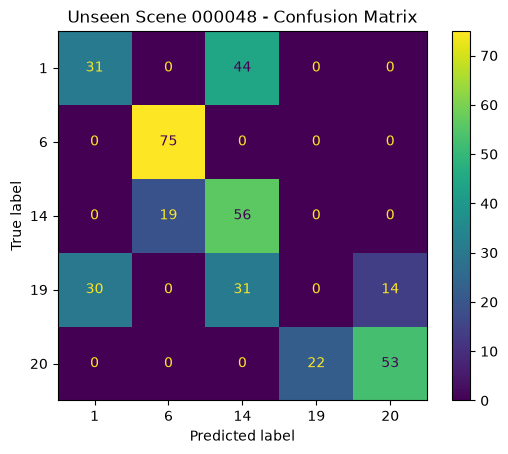

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_labels = sorted(y_test_unseen.unique())

cm_unseen = confusion_matrix(
    y_test_unseen,
    y_test_unseen_pred,
    labels=test_labels
)

print("Confusion Matrix:")
print(cm_unseen)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_unseen,
    display_labels=test_labels
)

disp.plot()
plt.title("Unseen Scene 000048 - Confusion Matrix")
plt.show()

In [47]:
from sklearn.metrics import classification_report

report_unseen = classification_report(
    y_test_unseen,
    y_test_unseen_pred,
    labels=test_labels,
    target_names=[f"Object {label}" for label in test_labels],
    zero_division=0
)

print(report_unseen)

              precision    recall  f1-score   support

    Object 1       0.51      0.41      0.46        75
    Object 6       0.80      1.00      0.89        75
   Object 14       0.43      0.75      0.54        75
   Object 19       0.00      0.00      0.00        75
   Object 20       0.79      0.71      0.75        75

    accuracy                           0.57       375
   macro avg       0.50      0.57      0.53       375
weighted avg       0.50      0.57      0.53       375



In [48]:
error_analysis_df = test_scene_df[
    ["scene_id", "frame_id", "instance_id", "obj_id"]
].copy().reset_index(drop=True)

error_analysis_df["predicted_obj_id"] = y_test_unseen_pred

error_analysis_df["correct"] = (
    error_analysis_df["obj_id"]
    == error_analysis_df["predicted_obj_id"]
)

errors_only = error_analysis_df[
    ~error_analysis_df["correct"]
].copy()

print("Total errors:", len(errors_only))
print("\nMost common error pairs:")

print(
    errors_only
    .groupby(["obj_id", "predicted_obj_id"])
    .size()
    .sort_values(ascending=False)
)

Total errors: 160

Most common error pairs:
obj_id  predicted_obj_id
1       14                  44
19      14                  31
        1                   30
20      19                  22
14      6                   19
19      20                  14
dtype: int64


In [49]:
error_examples = errors_only[
    ["scene_id", "frame_id", "instance_id", "obj_id", "predicted_obj_id"]
].copy()

error_examples.head(10)

,scene_id,frame_id,instance_id,obj_id,predicted_obj_id
3,000048,1,3,19,1
8,000048,36,3,19,1
13,000048,47,3,19,1
18,000048,83,3,19,1
23,000048,112,3,19,1
28,000048,1024,3,19,1
33,000048,1027,3,19,1
38,000048,1059,3,19,1
43,000048,1074,3,19,1
47,000048,1075,2,14,6


In [50]:
# Select a few representative failure cases
selected_errors = errors_only[
    ((errors_only["obj_id"] == 19) & (errors_only["predicted_obj_id"] == 1)) |
    ((errors_only["obj_id"] == 1) & (errors_only["predicted_obj_id"] == 14)) |
    ((errors_only["obj_id"] == 20) & (errors_only["predicted_obj_id"] == 19))
].head(6)

selected_errors

,scene_id,frame_id,instance_id,obj_id,predicted_obj_id,correct
3,000048,1,3,19,1,False
8,000048,36,3,19,1,False
13,000048,47,3,19,1,False
18,000048,83,3,19,1,False
23,000048,112,3,19,1,False
28,000048,1024,3,19,1,False


In [53]:
error_visual_df = errors_only.copy()

error_visual_df["rgb_path"] = error_visual_df.apply(
    lambda row: (
        Path("test")
        / row["scene_id"]
        / "rgb"
        / f"{int(row['frame_id']):06d}.png"
    ),
    axis=1
)

error_visual_df["mask_path"] = error_visual_df.apply(
    lambda row: (
        Path("test")
        / row["scene_id"]
        / "mask_visib"
        / f"{int(row['frame_id']):06d}_{int(row['instance_id']):06d}.png"
    ),
    axis=1
)

error_visual_df.head()

,scene_id,frame_id,instance_id,obj_id,predicted_obj_id,correct,rgb_path,mask_path
3,000048,1,3,19,1,False,test/000048/rgb/000001.png,test/000048/mask_visib/000001_000003.png
8,000048,36,3,19,1,False,test/000048/rgb/000036.png,test/000048/mask_visib/000036_000003.png
13,000048,47,3,19,1,False,test/000048/rgb/000047.png,test/000048/mask_visib/000047_000003.png
18,000048,83,3,19,1,False,test/000048/rgb/000083.png,test/000048/mask_visib/000083_000003.png
23,000048,112,3,19,1,False,test/000048/rgb/000112.png,test/000048/mask_visib/000112_000003.png


In [54]:
print("RGB exists:",
      error_visual_df.iloc[0]["rgb_path"].exists())

print("Mask exists:",
      error_visual_df.iloc[0]["mask_path"].exists())

print("RGB path:",
      error_visual_df.iloc[0]["rgb_path"])

print("Mask path:",
      error_visual_df.iloc[0]["mask_path"])

RGB exists: True
Mask exists: True
RGB path: test/000048/rgb/000001.png
Mask path: test/000048/mask_visib/000001_000003.png


In [55]:
selected_errors = pd.concat([
    error_visual_df[
        (error_visual_df["obj_id"] == 19) &
        (error_visual_df["predicted_obj_id"] == 1)
    ].head(2),

    error_visual_df[
        (error_visual_df["obj_id"] == 1) &
        (error_visual_df["predicted_obj_id"] == 14)
    ].head(2),

    error_visual_df[
        (error_visual_df["obj_id"] == 20) &
        (error_visual_df["predicted_obj_id"] == 19)
    ].head(2)
])

selected_errors[
    ["frame_id", "instance_id", "obj_id", "predicted_obj_id"]
]

,frame_id,instance_id,obj_id,predicted_obj_id
3,1,3,19,1
8,36,3,19,1
95,1119,0,1,14
100,1120,0,1,14
184,1577,4,20,19
189,1579,4,20,19


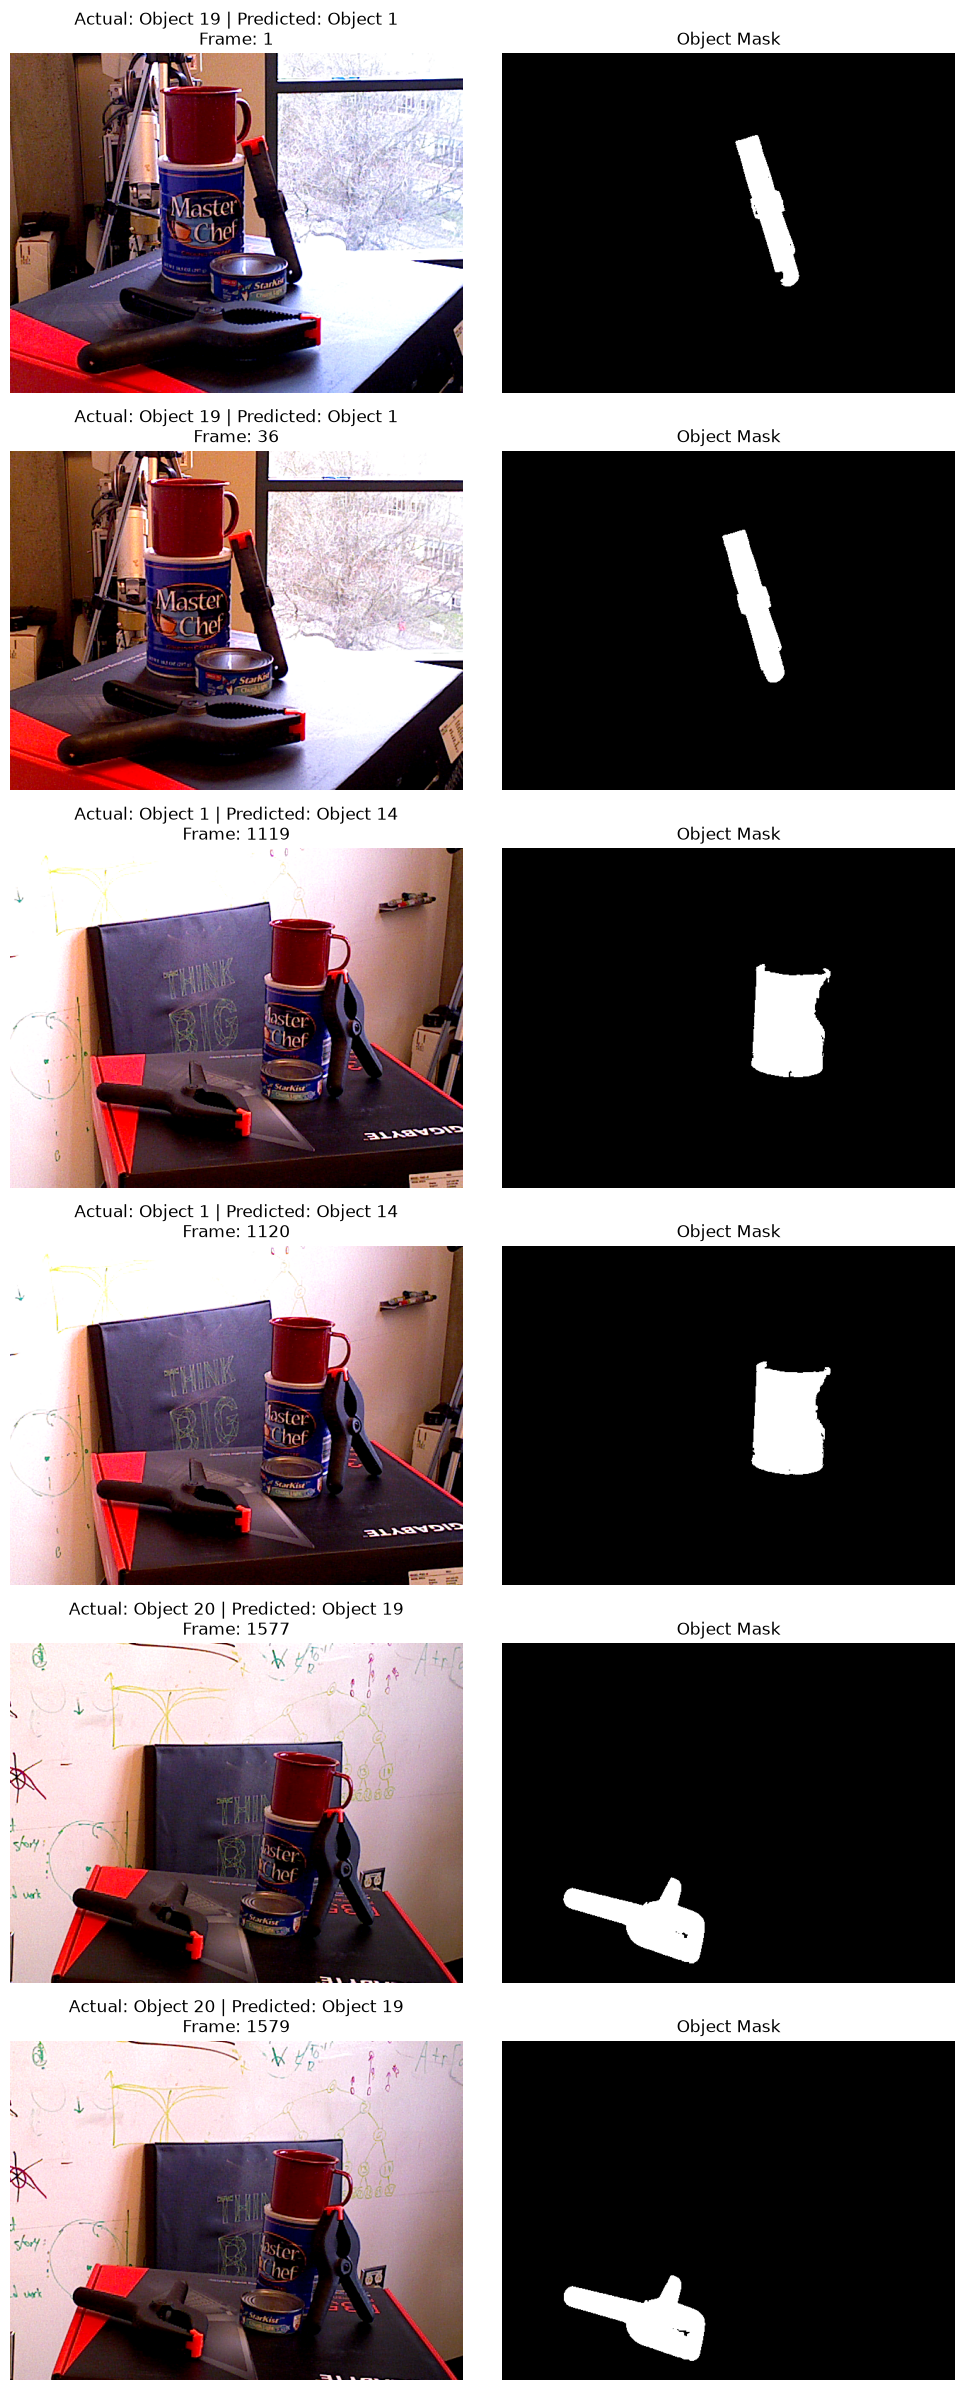

In [57]:
fig, axes = plt.subplots(
    len(selected_errors),
    2,
    figsize=(10, 4 * len(selected_errors))
)

for i, (_, row) in enumerate(selected_errors.iterrows()):

    rgb = Image.open(row["rgb_path"]).convert("RGB")
    mask = Image.open(row["mask_path"]).convert("L")

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(
        f"Actual: Object {row['obj_id']} | "
        f"Predicted: Object {row['predicted_obj_id']}\n"
        f"Frame: {row['frame_id']}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Object Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()